## Overview

In this notebook, the following datasets from the **2011 Census of England and Wales** have been used:

- Car or van availability  
- Age structure  
- Distance travelled to work  
- Economic activity  

The analysis includes **data cleaning**, **data transformation**, **feature selection**, and **dimensionality reduction techniques** such as **PCA**, **t-SNE** and **UMAP**.


In [3]:
# Import libraries for data handling, scaling, PCA, and visualization

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [4]:
# Load datasets

df_car = pd.read_csv("Car or van.csv")
df_age = pd.read_csv("age.csv")
df_distance_travelled = pd.read_csv("Distance_travelled_to _work.csv")
df_economic_act = pd.read_csv("economic activity.csv")

## Data Cleaning & Feature Selection

In this step, the datasets are being prepared for analysis by performing basic data cleaning and selecting relevant features.

### Data Cleaning
- Checking and correcting **data types** for consistency  
- Identification and handling of **missing values**  
- Removing **irrelevant or redundant columns**  
- Renaming columns where necessary for better readability. 

### Feature Selection
- Selecting only **relevant variables** for analysis  
- Focusing on features useful for **dimensionality reduction and visualisation**  
- Ensuring the data is in a suitable format for further processing  

This step ensures the datasets are clean, consistent, and ready for analysis.


## Car or Van Availability Dataset

In [5]:
df_car.head(5) # first five rows of the dataset

,date,geography,geography code,Rural Urban,Cars: All categories: Car or van availability; measures: Value,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Cars: sum of All cars or vans in the area; measures: Value
0,2011,Darlington,E06000005,Total,46670,13052,20682,10450,1962,524,49794
1,2011,County Durham,E06000047,Total,223803,60926,96086,52740,10775,3276,248586
2,2011,Hartlepool,E06000001,Total,40434,14268,16573,7662,1535,396,38269
3,2011,Middlesbrough,E06000002,Total,57203,21488,22963,10207,1945,600,51821
4,2011,Northumberland,E06000057,Total,138534,30543,60875,36916,7671,2529,168974


In [6]:
df_car.info() # dataset details

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 11 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   date                                                            174 non-null    int64
 1   geography                                                       174 non-null    str  
 2   geography code                                                  174 non-null    str  
 3   Rural Urban                                                     174 non-null    str  
 4   Cars: All categories: Car or van availability; measures: Value  174 non-null    int64
 5   Cars: No cars or vans in household; measures: Value             174 non-null    int64
 6   Cars: 1 car or van in household; measures: Value                174 non-null    int64
 7   Cars: 2 cars or vans in household; measures: Value              174 non-null    in

In [7]:
df_car.isna().sum()   # checking null values 

date                                                              0
geography                                                         0
geography code                                                    0
Rural Urban                                                       0
Cars: All categories: Car or van availability; measures: Value    0
Cars: No cars or vans in household; measures: Value               0
Cars: 1 car or van in household; measures: Value                  0
Cars: 2 cars or vans in household; measures: Value                0
Cars: 3 cars or vans in household; measures: Value                0
Cars: 4 or more cars or vans in household; measures: Value        0
Cars: sum of All cars or vans in the area; measures: Value        0
dtype: int64

In [8]:
df_car.shape # shape of the dataset

(174, 11)

Redundant columns were removed to reduce noise in the dataset, improve dimensionality reduction, and enhance the efficiency and interpretability of subsequent analysis.

In [9]:
df_car = df_car.drop(["date", "Cars: All categories: Car or van availability; measures: Value", "Cars: sum of All cars or vans in the area; measures: Value"], axis = 1)

In [10]:
df_car_cp = df_car.copy() # creating a copy 

In [11]:
numeric_columns = df_car_cp.select_dtypes(include = "number").columns # selecting columns which have numerical data

To ensure that variations in population size do not bias the analysis, the raw population figures were normalised by converting them into proportional values. This allows for a more meaningful comparison across regions by controlling for differences in scale and helps to rule out the influence of areas with disproportionately high absolute population numbers.

In [12]:
df_car_cp[numeric_columns] = df_car_cp[numeric_columns].div(df_car_cp[numeric_columns].sum(axis =1), axis =0)

In [13]:
df_car_cp.head(4)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value
0,Darlington,E06000005,Total,0.279666,0.443154,0.223913,0.042040,0.011228
1,County Durham,E06000047,Total,0.272230,0.429333,0.235654,0.048145,0.014638
2,Hartlepool,E06000001,Total,0.352871,0.409878,0.189494,0.037963,0.009794
3,Middlesbrough,E06000002,Total,0.375645,0.401430,0.178435,0.034002,0.010489


## Age Structure Dataset

In [14]:
df_age.head(5) # first five rows

,date,geography,geography code,Rural Urban,Age: All usual residents; measures: Value,Age: Age 0 to 4; measures: Value,Age: Age 5 to 7; measures: Value,Age: Age 8 to 9; measures: Value,Age: Age 10 to 14; measures: Value,Age: Age 15; measures: Value,...,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value,Age: Mean Age; measures: Value,Age: Median Age; measures: Value
0,2011,Darlington,E06000005,Total,105564,6579,3790,2284,6224,1330,...,6607,20917,21560,6685,9717,6172,1740,810,40.2,41.0
1,2011,County Durham,E06000047,Total,513242,28574,15818,9841,27869,5882,...,30628,96150,108200,35395,50883,30635,7321,3506,41.0,42.0
2,2011,Hartlepool,E06000001,Total,92028,5698,3202,1990,5653,1257,...,5622,16869,19326,5837,8174,5568,1323,533,39.8,40.0
3,2011,Middlesbrough,E06000002,Total,138412,9431,5178,3098,8485,1811,...,9765,25414,27065,7531,10833,7393,1658,807,37.8,37.0
4,2011,Northumberland,E06000057,Total,316028,16003,9863,6482,17677,3841,...,16187,56156,71135,24533,34366,21018,5233,2687,42.8,45.0


In [15]:
df_age.shape # shape of the dataset

(174, 23)

In [16]:
df_age.info() # information

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   date                                       174 non-null    int64  
 1   geography                                  174 non-null    str    
 2   geography code                             174 non-null    str    
 3   Rural Urban                                174 non-null    str    
 4   Age: All usual residents; measures: Value  174 non-null    int64  
 5   Age: Age 0 to 4; measures: Value           174 non-null    int64  
 6   Age: Age 5 to 7; measures: Value           174 non-null    int64  
 7   Age: Age 8 to 9; measures: Value           174 non-null    int64  
 8   Age: Age 10 to 14; measures: Value         174 non-null    int64  
 9   Age: Age 15; measures: Value               174 non-null    int64  
 10  Age: Age 16 to 17; measures: Value   

Redundant columns were removed to reduce noise in the dataset, improve dimensionality reduction, and enhance the efficiency and interpretability of subsequent analysis.

In [17]:
df_age = df_age.drop(["date", "Age: All usual residents; measures: Value","Age: Mean Age; measures: Value", "Age: Median Age; measures: Value" ], axis = 1)

In [18]:
df_age.head(5) 

,geography,geography code,Rural Urban,Age: Age 0 to 4; measures: Value,Age: Age 5 to 7; measures: Value,Age: Age 8 to 9; measures: Value,Age: Age 10 to 14; measures: Value,Age: Age 15; measures: Value,Age: Age 16 to 17; measures: Value,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,Darlington,E06000005,Total,6579,3790,2284,6224,1330,2721,2357,6071,6607,20917,21560,6685,9717,6172,1740,810
1,County Durham,E06000047,Total,28574,15818,9841,27869,5882,12107,15278,35155,30628,96150,108200,35395,50883,30635,7321,3506
2,Hartlepool,E06000001,Total,5698,3202,1990,5653,1257,2570,2451,5955,5622,16869,19326,5837,8174,5568,1323,533
3,Middlesbrough,E06000002,Total,9431,5178,3098,8485,1811,3747,4506,11690,9765,25414,27065,7531,10833,7393,1658,807
4,Northumberland,E06000057,Total,16003,9863,6482,17677,3841,7631,6992,16224,16187,56156,71135,24533,34366,21018,5233,2687


In [19]:
df_age_cp = df_age.copy()

In [20]:
numeric_columns = df_age_cp.select_dtypes(include="number").columns  # to select numerical columns

In [21]:
df_age_cp[numeric_columns] = df_age_cp[numeric_columns].div(df_age_cp[numeric_columns].sum(axis =1), axis=0) #converting into proportions

## Distance Travelled To work Dataset

In [22]:
df_distance_travelled.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 17 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   date                                                                                     174 non-null    int64  
 1   geography                                                                                174 non-null    str    
 2   geography code                                                                           174 non-null    str    
 3   Rural Urban                                                                              174 non-null    str    
 4   Distance travelled to work: All categories: Distance travelled to work; measures: Value  174 non-null    int64  
 5   Distance travelled to work: Less than 2km; measures: Value                 

In [23]:
df_distance_travelled.shape

(174, 17)

In [24]:
df_distance_travelled.isna().sum()

date                                                                                       0
geography                                                                                  0
geography code                                                                             0
Rural Urban                                                                                0
Distance travelled to work: All categories: Distance travelled to work; measures: Value    0
Distance travelled to work: Less than 2km; measures: Value                                 0
Distance travelled to work: 2km to less than 5km; measures: Value                          0
Distance travelled to work: 5km to less than 10km; measures: Value                         0
Distance travelled to work: 10km to less than 20km; measures: Value                        0
Distance travelled to work: 20km to less than 30km; measures: Value                        0
Distance travelled to work: 30km to less than 40km; measures: Value   

In [25]:
df_distance_travelled = df_distance_travelled.drop(["date", "Distance travelled to work: All categories: Distance travelled to work; measures: Value","Distance travelled to work: Total distance (km); measures: Value", "Distance travelled to work: Average distance (km); measures: Value"], axis = 1)

In [26]:
df_distance_travelled.head(5)

,geography,geography code,Rural Urban,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,Distance travelled to work: 5km to less than 10km; measures: Value,Distance travelled to work: 10km to less than 20km; measures: Value,Distance travelled to work: 20km to less than 30km; measures: Value,Distance travelled to work: 30km to less than 40km; measures: Value,Distance travelled to work: 40km to less than 60km; measures: Value,Distance travelled to work: 60km and over; measures: Value,Distance travelled to work: Work mainly at or from home; measures: Value,Distance travelled to work: Other; measures: Value
0,Darlington,E06000005,Total,11433,12516,4226,5552,4410,793,1234,1502,4180,3168
1,County Durham,E06000047,Total,36588,31877,38010,51191,19810,6846,2222,5704,20652,14994
2,Hartlepool,E06000001,Total,8452,10557,3406,5707,1684,681,489,1154,2473,3164
3,Middlesbrough,E06000002,Total,10393,15799,11414,4137,1281,642,848,1733,3337,4963
4,Northumberland,E06000057,Total,25944,14491,19568,30255,12969,5666,4162,5593,17894,10359


In [27]:
df_dist_cp = df_distance_travelled.copy()
numeric_columns = df_dist_cp.select_dtypes(include="number").columns
df_dist_cp[numeric_columns] = df_dist_cp[numeric_columns].div(df_dist_cp[numeric_columns].sum(axis =1), axis=0)


## Economic Activity

In [28]:
df_economic_act.head(5)

,date,geography,geography code,Rural Urban,Economic Activity: All categories: Economic activity; measures: Value,Economic Activity: Economically active: Total; measures: Value,Economic Activity: Economically active: Employee: Part-time; measures: Value,Economic Activity: Economically active: Employee: Full-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value,Economic Activity: Economically active: Unemployed; measures: Value,Economic Activity: Economically active: Full-time student; measures: Value,Economic Activity: Economically inactive: Total; measures: Value,Economic Activity: Economically inactive: Retired; measures: Value,Economic Activity: Economically inactive: Student (including full-time students); measures: Value,Economic Activity: Economically inactive: Looking after home or family; measures: Value,Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value,Economic Activity: Economically inactive: Other; measures: Value
0,2011,Darlington,E06000005,Total,76635,53443,11555,30337,234,1254,1289,2818,4002,1954,23192,12214,2742,3081,3737,1418
1,2011,County Durham,E06000047,Total,383796,247101,50595,143922,1052,5717,5799,12741,17013,10262,136695,65444,23837,14190,24887,8337
2,2011,Hartlepool,E06000001,Total,66804,43513,10092,22635,212,846,892,1855,5194,1787,23291,10621,3042,3265,4733,1630
3,2011,Middlesbrough,E06000002,Total,100551,63582,15063,31301,300,1068,1331,2472,7631,4416,36969,13922,7453,5569,6841,3184
4,2011,Northumberland,E06000057,Total,233224,158268,34368,86380,993,5351,5151,10568,10329,5128,74956,43897,8108,8368,10321,4262


In [29]:
df_economic_act.shape

(174, 20)

In [30]:
df_economic_act.isna().sum()

date                                                                                                   0
geography                                                                                              0
geography code                                                                                         0
Rural Urban                                                                                            0
Economic Activity: All categories: Economic activity; measures: Value                                  0
Economic Activity: Economically active: Total; measures: Value                                         0
Economic Activity: Economically active: Employee: Part-time; measures: Value                           0
Economic Activity: Economically active: Employee: Full-time; measures: Value                           0
Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value       0
Economic Activity: Economically active: Self-employed w

In [31]:
df_economic_act = df_economic_act.drop(["date", "Economic Activity: All categories: Economic activity; measures: Value", "Economic Activity: Economically active: Total; measures: Value", "Economic Activity: Economically inactive: Total; measures: Value"], axis = 1)

In [32]:
df_economic_act.head(4)

,geography,geography code,Rural Urban,Economic Activity: Economically active: Employee: Part-time; measures: Value,Economic Activity: Economically active: Employee: Full-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value,Economic Activity: Economically active: Unemployed; measures: Value,Economic Activity: Economically active: Full-time student; measures: Value,Economic Activity: Economically inactive: Retired; measures: Value,Economic Activity: Economically inactive: Student (including full-time students); measures: Value,Economic Activity: Economically inactive: Looking after home or family; measures: Value,Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value,Economic Activity: Economically inactive: Other; measures: Value
0,Darlington,E06000005,Total,11555,30337,234,1254,1289,2818,4002,1954,12214,2742,3081,3737,1418
1,County Durham,E06000047,Total,50595,143922,1052,5717,5799,12741,17013,10262,65444,23837,14190,24887,8337
2,Hartlepool,E06000001,Total,10092,22635,212,846,892,1855,5194,1787,10621,3042,3265,4733,1630
3,Middlesbrough,E06000002,Total,15063,31301,300,1068,1331,2472,7631,4416,13922,7453,5569,6841,3184


In [33]:
df_eco_cp = df_economic_act.copy()
numeric_columns = df_eco_cp.select_dtypes(include="number").columns
df_eco_cp[numeric_columns] = df_eco_cp[numeric_columns].div(df_eco_cp[numeric_columns].sum(axis =1), axis=0)


## Merging Columns
After preprocessing each dataset individually, the next step involves merging them to enable a comprehensive, collective analysis and unified visualization of the combined data.

In [34]:
# Dropping non-numeric and identifier columns
# to prepare each dataset for merging and ensure consistency for collective analysis and visualization

df_age_merge = df_age.drop(["geography", "Rural Urban"], axis=1)
df_distance_travelled_merge = df_distance_travelled.drop(["geography", "Rural Urban"], axis=1)
df_economic_act_merg = df_economic_act.drop(["geography", "Rural Urban"], axis=1)

In [35]:
# Dropping non-numeric and identifier columns
# to prepare each dataset for merging and ensure consistency for collective analysis and visualization
df_age_merge_cp = df_age_cp.drop(["geography", "Rural Urban"], axis = 1)
df_distance_travelled_merge_cp = df_dist_cp.drop(["geography", "Rural Urban"], axis = 1)
df_economic_act_merg_cp =  df_eco_cp.drop(["geography", "Rural Urban"], axis = 1)

In [36]:
# merging the dataset
merged_df = df_car.merge(df_distance_travelled_merge, on = "geography code", how = "inner").merge(df_economic_act_merg, on = "geography code", how = "inner").merge(df_age_merge, on = "geography code", how = "inner")

In [37]:
merged_df_cp = df_car_cp.merge(df_distance_travelled_merge_cp, on = "geography code", how = "inner").merge(df_economic_act_merg_cp, on = "geography code", how = "inner").merge(df_age_merge_cp, on = "geography code", how = "inner")

In [38]:
final_df = merged_df.iloc[:, 3:]

In [39]:
final_df_cp = merged_df_cp.iloc[:, 3:]

## Dimensionality Reduction for High-Dimensional Socio-Economic Data using PCA, t-SNE, and UMAP

After preprocessing and merging the datasets, dimensionality reduction techniques are applied to transform the high-dimensional socio-economic features into a lower-dimensional space for effective visualization and interpretation. 

These approaches enable clearer visualization of relationships across regions and help in identifying meaningful socio-economic groupings in the dataset.



### Principle Component Analysis (PCA)

In [40]:
# Standardising the dataset to ensure all features contribute equally to the analysis
scalar = StandardScaler()
scaled_data = scalar.fit_transform(final_df_cp)

# Applying PCA to reduce the dataset to 2 principal components for 2D visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

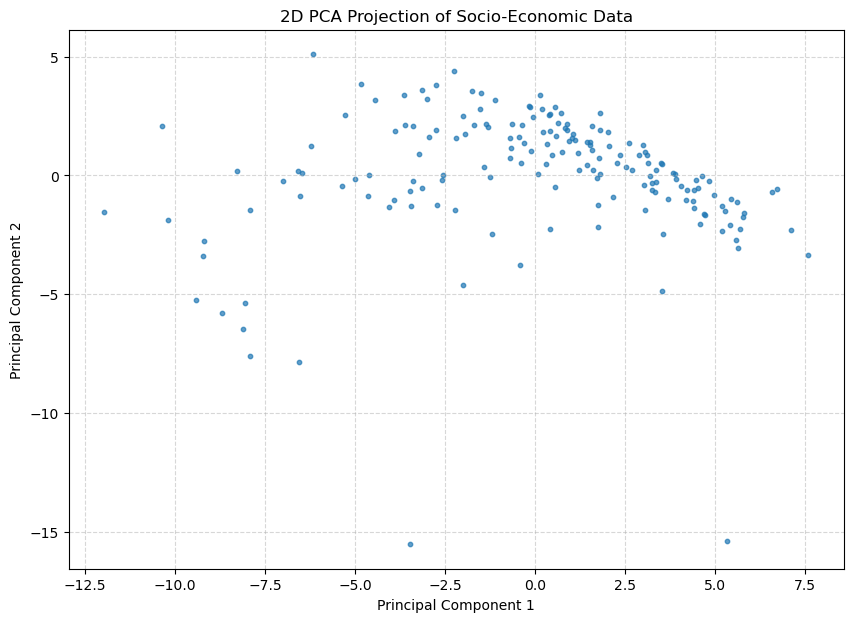

In [41]:
plt.figure(figsize=(10, 7))

# Scatter plot of PCA results
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=10, alpha=0.7)

# Axis labels
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Title
plt.title("2D PCA Projection of Socio-Economic Data")

# Grid for better readability
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### t-SNE (t-Distributed Stochastic Neighbor Embedding)

In [42]:
from sklearn.manifold import TSNE

# Initialising t-SNE for reducing the high-dimensional data into 2D space for visualization
# random_state is set for reproducibility of results
tsne = TSNE(n_components=2, random_state=1729)

# Applying t-SNE transformation on the scaled dataset to obtain 2D embedding
tsne_result = tsne.fit_transform(scaled_data)

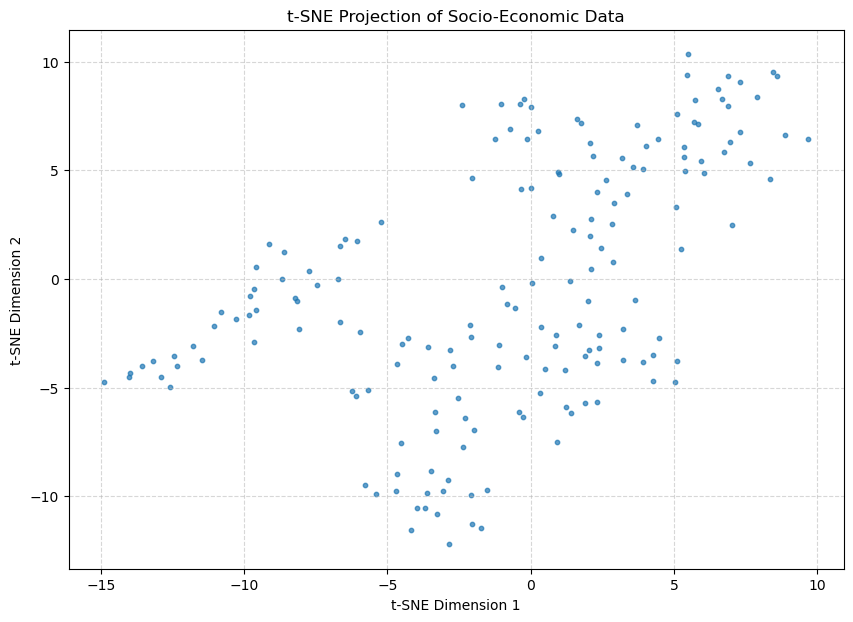

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Scatter plot for t-SNE results
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=10, alpha=0.7)

# Axis labels
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

# Title
plt.title("t-SNE Projection of Socio-Economic Data")

# Grid for better readability
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

#### t-SNE Visualization on PCA-Reduced Data (25 Components)

In this step, t-SNE is applied on the dataset after reducing its dimensionality to 25 principal components using PCA. This approach combines linear and non-linear dimensionality reduction techniques to achieve a more effective visualization of complex socio-economic data.

#### Why PCA before t-SNE? 

Applying PCA before t-SNE is considered a good practice for several reasons:

- **Noise reduction:** PCA helps remove redundant and less informative features from the dataset.  
- **Computational efficiency:** t-SNE is computationally expensive, and reducing dimensions first significantly speeds up the process.  
- **Improved stability:** PCA reduces sparsity and high-dimensional noise, leading to more stable and meaningful t-SNE embeddings.  
- **Better structure preservation:** Retaining the top 25 components ensures that most of the important variance in the data is preserved before applying non-linear mapping.

t-SNE is then used on this reduced feature space to capture complex, non-linear relationships and reveal local clustering patterns in a 2D visualization.

This combined PCA → t-SNE approach provides a more robust and interpretable representation of the underlying socio-economic structure compared to using t-SNE alone.
```


In [44]:
# Reducing dimensionality using PCA to retain 25 principal components
# This step helps in removing noise, reducing redundancy, and improving computational efficiency
pca = PCA(n_components=25)
pca_res = pca.fit_transform(scaled_data)

# Applying t-SNE on PCA-reduced data to project it into 2D space
# random_state ensures reproducibility of the visualization results
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=1729)
tsne_result = tsne.fit_transform(pca_res)

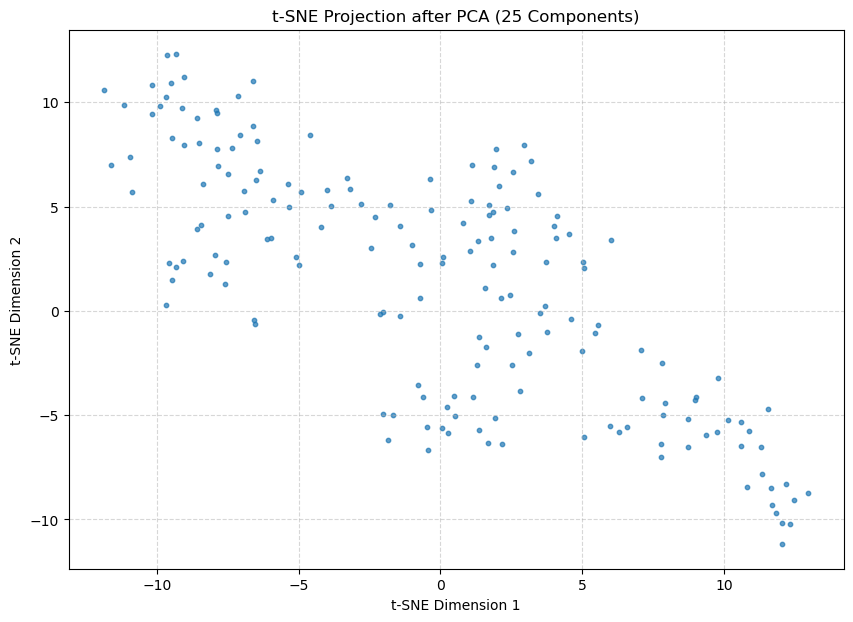

In [85]:
plt.figure(figsize=(10, 7))

# Scatter plot of t-SNE results
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=10, alpha=0.7)

# Axis labels
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

# Title
plt.title("t-SNE Projection after PCA (25 Components)")

# Grid for better readability
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### UMAP (Uniform Manifold Approximation and Projection)

Uniform Manifold Approximation and Projection (UMAP) is applied to reduce the high-dimensional socio-economic dataset into a 2D space for visualization. Unlike linear methods, UMAP preserves both local neighborhood structure and global data relationships, making it highly effective for identifying meaningful clusters and patterns. This allows for a more interpretable representation of complex socio-economic structures across regions.

c:\Users\Aman Kumar Singh\anaconda3\envs\text_analytics\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


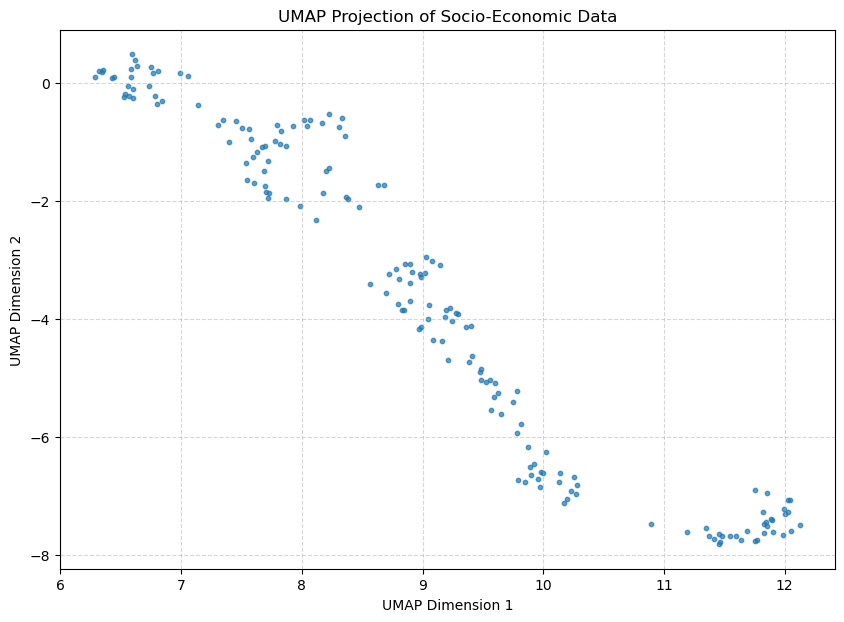

In [46]:
from umap.umap_ import UMAP

# Initialising UMAP for dimensionality reduction
# n_components=5 reduces data into 5 dimensions before visualization
# min_dist controls how tightly points are packed in the low-dimensional space
# random_state ensures reproducibility of results
umap = UMAP(n_components=5, min_dist=0.01, random_state=400)

# Fitting UMAP on the scaled dataset and transforming it into lower-dimensional embedding
embedding = umap.fit_transform(scaled_data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Scatter plot of first two UMAP components for visualization
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, alpha=0.7)

# Axis labels
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

# Title
plt.title("UMAP Projection of Socio-Economic Data")

# Grid for better readability
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### K-Means Clustering on UMAP-Reduced Components

To identify meaningful groups within the socio-economic dataset, K-Means clustering is applied on the lower-dimensional representation obtained from UMAP. The UMAP algorithm first transforms the high-dimensional data into a compact embedding while preserving both local and global structure.

These UMAP components are then used as input for K-Means clustering to assign each observation to a distinct cluster based on similarity.

This combined approach helps in generating more interpretable and well-separated clusters, which can then be used to analyse underlying socio-economic patterns across regions.

In [47]:
import seaborn as sns
from sklearn.cluster import KMeans

# Applying K-Means clustering on the UMAP embedding to identify distinct groups in the data
# n_clusters defines the number of clusters to form
# random_state ensures reproducibility of cluster assignments
kmean = KMeans(n_clusters=4, random_state=1429)

# Generating cluster labels for each data point based on the UMAP components
cluster_label = kmean.fit_predict(embedding)

# Creating a DataFrame to store UMAP components along with their assigned cluster labels
embedds = pd.DataFrame({
    "Col1": embedding[:, 0],
    "Col2": embedding[:, 1],
    "cluster": cluster_label
})

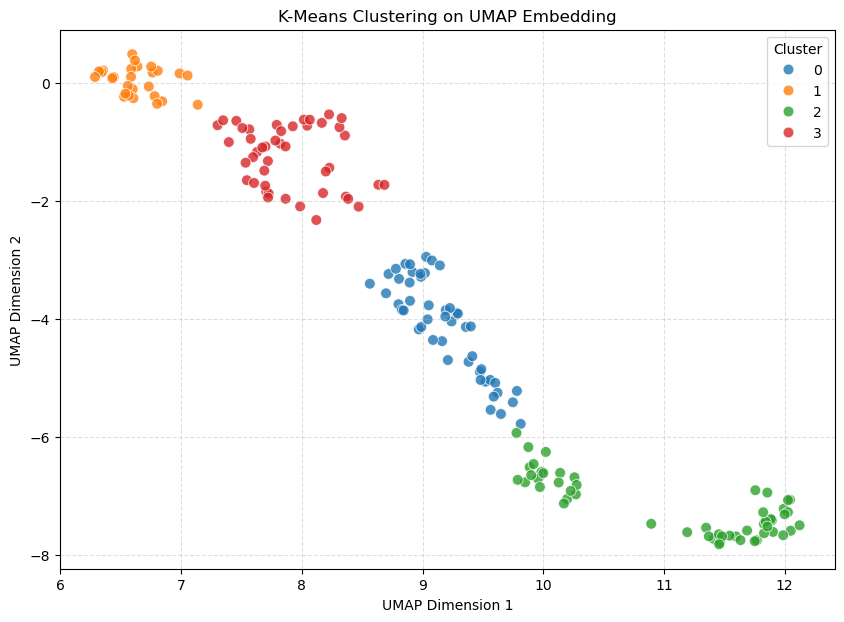

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Scatter plot of UMAP components colored by K-Means cluster labels
sns.scatterplot(
    data=embedds,
    x="Col1",
    y="Col2",
    hue="cluster",
    palette="tab10",
    s=60,
    alpha=0.8
)

# Axis labels
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

# Title
plt.title("K-Means Clustering on UMAP Embedding")

# Legend
plt.legend(title="Cluster")

# Grid for better readability
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

In [57]:
merged_df["cluster"] = cluster_label
merged_df["P1"] = embedding[:, 0]
merged_df["P2"] = embedding[:, 1]


In [59]:
merged_df = merged_df.drop("Col1",axis=1)

In [60]:
merged_df.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,...,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value,cluster,P1,P2
0,Darlington,E06000005,Total,13052,20682,10450,1962,524,11433,12516,...,20917,21560,6685,9717,6172,1740,810,3,8.120296,-2.323253
1,County Durham,E06000047,Total,60926,96086,52740,10775,3276,36588,31877,...,96150,108200,35395,50883,30635,7321,3506,0,8.916958,-3.204791
2,Hartlepool,E06000001,Total,14268,16573,7662,1535,396,8452,10557,...,16869,19326,5837,8174,5568,1323,533,0,9.162120,-4.377292
3,Middlesbrough,E06000002,Total,21488,22963,10207,1945,600,10393,15799,...,25414,27065,7531,10833,7393,1658,807,0,9.813269,-5.781488
4,Northumberland,E06000057,Total,30543,60875,36916,7671,2529,25944,14491,...,56156,71135,24533,34366,21018,5233,2687,1,6.843403,-0.309240


In [62]:
merged_df.to_csv("Preprocessed Data.csv") # Saving data file for further analysis



##  Data Preprocessing for Analysis of Age Structure (2011 vs 2021 Census Data)

The dataset is preprocessed to enable a comparative analysis of age structure between the 2011 and 2021 census data. This involves cleaning the raw data, handling missing values, standardising column formats, and ensuring consistency across both time periods. Relevant features are selected, and non-essential or redundant columns are removed to improve data quality and analytical efficiency. These steps ensure that the dataset is well-structured and suitable for meaningful temporal comparison and further statistical or visual analysis.
```


In [64]:
df11 = pd.read_csv("bulk (2).csv") # reading dataset

In [65]:
tempo_df = pd.read_csv("Chart2.csv") # reading dataset

In [66]:
df21 = pd.read_csv("census2021-ts007-utla (Age).csv") # reading dataset

In [67]:
# dropping irrelevant columns
df21 = df21.drop(["Age: Aged 4 years and under; measures: Value",
                  "Age: Aged 5 to 9 years; measures: Value", 
                  "Age: Aged 10 to 15 years; measures: Value", 
                  "Age: Aged 16 to 19 years; measures: Value", 
                  "Age: Aged 20 to 24 years; measures: Value",
                  "Age: Aged 25 to 34 years; measures: Value",
                  "Age: Aged 35 to 49 years; measures: Value",
                  "Age: Aged 50 to 64 years; measures: Value",
                  "Age: Aged 65 to 74 years; measures: Value",
                  "Age: Aged 75 to 84 years; measures: Value",
                  "Age: Aged 50 to 64 years; measures: Value",
                  "Age: Aged 85 years and over; measures: Value",
                  "date",
                  "Age: Total; measures: Value"], axis =1)

In [68]:
df21.columns = ["geography", 'geography code'] + [str(i) for i in range(0,100)] + ["100+"]

In [69]:
df21.head(5) # first five rows

,geography,geography code,0,1,2,3,4,5,6,7,...,91,92,93,94,95,96,97,98,99,100+
0,Darlington,E06000005,1040,1048,1109,1167,1130,1220,1229,1257,...,178,137,105,104,73,53,20,38,25,22
1,County Durham,E06000047,4623,4809,4969,4990,5361,5534,5468,5650,...,834,633,446,369,284,235,127,92,62,87
2,Hartlepool,E06000001,918,954,1046,988,1077,1109,1032,1097,...,130,110,92,62,48,30,19,19,14,21
3,Middlesbrough,E06000002,1621,1720,1766,1908,1913,1861,1920,1950,...,217,153,112,82,61,47,38,18,15,22
4,Northumberland,E06000057,2575,2631,2905,2985,3139,3231,3191,3280,...,611,514,383,316,219,177,114,67,49,80


In [70]:
df21_bands = df21[[	"geography", "geography code"]]

In [71]:

#Creating aggregated age bands from detailed age columns (2021 Census data)

# Summing columns corresponding to ages 0–19 to form a single age group
df21_bands["0--19"] = df21.iloc[:, 2:22].sum(axis=1)

# Summing columns corresponding to ages 20–64 to form working-age population group
df21_bands["20--64"] = df21.iloc[:, 22:67].sum(axis=1)

# Summing remaining columns (65+) to form elderly population group
df21_bands["65--"] = df21.iloc[:, 67:].sum(axis=1)



In [72]:
# Extracting unique geography codes from both 2011 and 2021 datasets
codes_2011 = set(tempo_df['geography'])
codes_2021 = set(df21_bands['geography'])

# Identifying regions present in 2011 but missing in 2021
missing_in_2021 = codes_2011 - codes_2021

# Identifying regions present in 2021 but missing in 2011
missing_in_2011 = codes_2021 - codes_2011

# Printing discrepancies in geography coverage between the two census datasets
print("Missing in 2021:", missing_in_2021)
print("Missing in 2011:", missing_in_2011)

Missing in 2021: set()
Missing in 2011: set()


In [73]:
# Merging 2011 and 2021 datasets on 'geography code' to compare coverage across both years
# 'outer' join ensures all records from both datasets are retained
# '_merge' column indicates the source of each row (left_only, right_only, or both)
merged = tempo_df.merge(
    df21_bands,
    on='geography code',
    how='outer',
    indicator=True
)

# Extracting geography codes that exist only in the 2011 dataset
only_2011 = merged[merged['_merge'] == 'left_only']['geography code']

# Extracting geography codes that exist only in the 2021 dataset
only_2021 = merged[merged['_merge'] == 'right_only']['geography code']

# Displaying unmatched regions between the two census datasets
print("Only in 2011:\n", only_2011.tolist())
print("\nOnly in 2021:\n", only_2021.tolist())

Only in 2011:
 ['E06000029', 'E10000002', 'E10000009', 'E10000021']

Only in 2021:
 ['E06000058']


In [74]:
data11_21 = tempo_df.merge(df21_bands, on = "geography", how = "inner")  # merging

In [75]:
data11_21 = data11_21[["geography code_x", "geography", "Young 0-19", "Working-age 20-64", "Retired-age 65-90", "0--19",
 "20--64",
 "65--"]]

In [76]:
mk = pd.read_csv("Cleaned_Data\Data.csv") # raading the dataset

In [77]:
mk = mk[["geography", "cluster"]]

In [78]:
Data11_21 = data11_21.merge(mk, on = "geography", how = "inner") # merging

In [ ]:
Data11_21.to_csv("Data21-11.csv") # writing the

In [ ]:
mk = mk[["geography", "cluster"]] 

In [ ]:
cd = pd.read_csv("Data21-11.csv") # reading 

In [ ]:
Data11_21 = cd.merge(mk, on = "geography", how = "inner") # merging

In [ ]:
Data11_21.to_csv("Data21-11.csv") # Data writing 

## Data Aggregation and Transformation

After completing the initial stages of data cleaning, preprocessing, and exploratory analysis, the dataset is further prepared for visualization through aggregation and transformation.

These steps are essential to reduce the granularity of the data by summarising detailed attributes into more meaningful and interpretable groups. This helps in simplifying complex datasets while preserving the key information required for analysis.

Aggregation and transformation are crucial for:
- Ensuring clearer and more interpretable visualizations  
- Avoiding overcrowded or cluttered charts  
- Highlighting broader patterns and trends across regions and time periods  

By structuring the data in a more compact and meaningful form, it becomes better suited for effective visualization and comparative analysis.

In [88]:
# reading dataset
df_car = pd.read_csv("Car or van.csv")
df_age = pd.read_csv("age.csv")
df_distance_travelled = pd.read_csv("Distance_travelled_to _work.csv")
df_economic_act = pd.read_csv("economic activity.csv")

In [ ]:
#dropping columns
df_car = df_car.drop(["date", "Cars: All categories: Car or van availability; measures: Value", "Cars: sum of All cars or vans in the area; measures: Value"], axis = 1)

In [90]:
df_car["Cars: (2, 3, 4) car or van in household; measures: Value"] = df_car["Cars: 2 cars or vans in household; measures: Value"] + df_car["Cars: 3 cars or vans in household; measures: Value"] + df_car["Cars: 4 or more cars or vans in household; measures: Value"]

In [91]:
df_car = df_car.drop(["Cars: 2 cars or vans in household; measures: Value", "Cars: 3 cars or vans in household; measures: Value", "Cars: 4 or more cars or vans in household; measures: Value"], axis =1)

In [92]:
df_car.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,"Cars: (2, 3, 4) car or van in household; measures: Value"
0,Darlington,E06000005,Total,13052,20682,12936
1,County Durham,E06000047,Total,60926,96086,66791
2,Hartlepool,E06000001,Total,14268,16573,9593
3,Middlesbrough,E06000002,Total,21488,22963,12752
4,Northumberland,E06000057,Total,30543,60875,47116


In [93]:
df_age = df_age.drop(["date", "Age: All usual residents; measures: Value","Age: Mean Age; measures: Value", "Age: Median Age; measures: Value" ], axis = 1)

In [94]:
df_age.head(5)

,geography,geography code,Rural Urban,Age: Age 0 to 4; measures: Value,Age: Age 5 to 7; measures: Value,Age: Age 8 to 9; measures: Value,Age: Age 10 to 14; measures: Value,Age: Age 15; measures: Value,Age: Age 16 to 17; measures: Value,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,Darlington,E06000005,Total,6579,3790,2284,6224,1330,2721,2357,6071,6607,20917,21560,6685,9717,6172,1740,810
1,County Durham,E06000047,Total,28574,15818,9841,27869,5882,12107,15278,35155,30628,96150,108200,35395,50883,30635,7321,3506
2,Hartlepool,E06000001,Total,5698,3202,1990,5653,1257,2570,2451,5955,5622,16869,19326,5837,8174,5568,1323,533
3,Middlesbrough,E06000002,Total,9431,5178,3098,8485,1811,3747,4506,11690,9765,25414,27065,7531,10833,7393,1658,807
4,Northumberland,E06000057,Total,16003,9863,6482,17677,3841,7631,6992,16224,16187,56156,71135,24533,34366,21018,5233,2687


In [ ]:
#Aggregation
df_age["Young 0-19"] = df_age["Age: Age 0 to 4; measures: Value"] + df_age["Age: Age 5 to 7; measures: Value"] + df_age["Age: Age 8 to 9; measures: Value"] + df_age["Age: Age 10 to 14; measures: Value"] + df_age["Age: Age 15; measures: Value"] + df_age["Age: Age 16 to 17; measures: Value"] + df_age["Age: Age 18 to 19; measures: Value"]

In [96]:
df_age["Working-age 20-64"] = df_age["Age: Age 20 to 24; measures: Value"] + df_age["Age: Age 25 to 29; measures: Value"] + df_age["Age: Age 30 to 44; measures: Value"] + df_age["Age: Age 45 to 59; measures: Value"] + df_age["Age: Age 60 to 64; measures: Value"]

In [97]:
df_age["Retired-age 65-90"] = df_age["Age: Age 65 to 74; measures: Value"] + df_age["Age: Age 75 to 84; measures: Value"] + df_age["Age: Age 85 to 89; measures: Value"] + df_age["Age: Age 90 and over; measures: Value"]

In [98]:
df_age.columns.tolist()

['geography',
 'geography code',
 'Rural Urban',
 'Age: Age 0 to 4; measures: Value',
 'Age: Age 5 to 7; measures: Value',
 'Age: Age 8 to 9; measures: Value',
 'Age: Age 10 to 14; measures: Value',
 'Age: Age 15; measures: Value',
 'Age: Age 16 to 17; measures: Value',
 'Age: Age 18 to 19; measures: Value',
 'Age: Age 20 to 24; measures: Value',
 'Age: Age 25 to 29; measures: Value',
 'Age: Age 30 to 44; measures: Value',
 'Age: Age 45 to 59; measures: Value',
 'Age: Age 60 to 64; measures: Value',
 'Age: Age 65 to 74; measures: Value',
 'Age: Age 75 to 84; measures: Value',
 'Age: Age 85 to 89; measures: Value',
 'Age: Age 90 and over; measures: Value',
 'Young 0-19',
 'Working-age 20-64',
 'Retired-age 65-90']

In [99]:
df_age = df_age.drop(['Rural Urban',
 'Age: Age 0 to 4; measures: Value',
 'Age: Age 5 to 7; measures: Value',
 'Age: Age 8 to 9; measures: Value',
 'Age: Age 10 to 14; measures: Value',
 'Age: Age 15; measures: Value',
 'Age: Age 16 to 17; measures: Value',
 'Age: Age 18 to 19; measures: Value',
 'Age: Age 20 to 24; measures: Value',
 'Age: Age 25 to 29; measures: Value',
 'Age: Age 30 to 44; measures: Value',
 'Age: Age 45 to 59; measures: Value',
 'Age: Age 60 to 64; measures: Value',
 'Age: Age 65 to 74; measures: Value',
 'Age: Age 75 to 84; measures: Value',
 'Age: Age 85 to 89; measures: Value',
 'Age: Age 90 and over; measures: Value', "geography"], axis =1)

In [100]:
df_age.head(5)

,geography code,Young 0-19,Working-age 20-64,Retired-age 65-90
0,E06000005,25285,61840,18439
1,E06000047,115369,305528,92345
2,E06000001,22821,53609,15598
3,E06000002,36256,81465,20691
4,E06000057,68489,184235,63304


In [101]:
df_distance_travelled = df_distance_travelled.drop(["date", "Distance travelled to work: All categories: Distance travelled to work; measures: Value","Distance travelled to work: Total distance (km); measures: Value", "Distance travelled to work: Average distance (km); measures: Value"], axis = 1)

In [102]:
df_distance_travelled.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 13 columns):
 #   Column                                                                    Non-Null Count  Dtype
---  ------                                                                    --------------  -----
 0   geography                                                                 174 non-null    str  
 1   geography code                                                            174 non-null    str  
 2   Rural Urban                                                               174 non-null    str  
 3   Distance travelled to work: Less than 2km; measures: Value                174 non-null    int64
 4   Distance travelled to work: 2km to less than 5km; measures: Value         174 non-null    int64
 5   Distance travelled to work: 5km to less than 10km; measures: Value        174 non-null    int64
 6   Distance travelled to work: 10km to less than 20km; measures: Value       174 non-null    int

In [103]:
df_distance_travelled.head(5)

,geography,geography code,Rural Urban,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,Distance travelled to work: 5km to less than 10km; measures: Value,Distance travelled to work: 10km to less than 20km; measures: Value,Distance travelled to work: 20km to less than 30km; measures: Value,Distance travelled to work: 30km to less than 40km; measures: Value,Distance travelled to work: 40km to less than 60km; measures: Value,Distance travelled to work: 60km and over; measures: Value,Distance travelled to work: Work mainly at or from home; measures: Value,Distance travelled to work: Other; measures: Value
0,Darlington,E06000005,Total,11433,12516,4226,5552,4410,793,1234,1502,4180,3168
1,County Durham,E06000047,Total,36588,31877,38010,51191,19810,6846,2222,5704,20652,14994
2,Hartlepool,E06000001,Total,8452,10557,3406,5707,1684,681,489,1154,2473,3164
3,Middlesbrough,E06000002,Total,10393,15799,11414,4137,1281,642,848,1733,3337,4963
4,Northumberland,E06000057,Total,25944,14491,19568,30255,12969,5666,4162,5593,17894,10359


In [104]:
df_distance_travelled["Distance < 10 km"] = df_distance_travelled["Distance travelled to work: Less than 2km; measures: Value"] + df_distance_travelled["Distance travelled to work: 2km to less than 5km; measures: Value"] + df_distance_travelled["Distance travelled to work: 5km to less than 10km; measures: Value"]

In [105]:
df_distance_travelled["10 km < Distance < 30 km"] = df_distance_travelled["Distance travelled to work: 10km to less than 20km; measures: Value"] + df_distance_travelled["Distance travelled to work: 20km to less than 30km; measures: Value"]

In [106]:
df_distance_travelled["30 km < Distanc < 60 km"] = df_distance_travelled["Distance travelled to work: 30km to less than 40km; measures: Value"] + df_distance_travelled["Distance travelled to work: 40km to less than 60km; measures: Value"] + df_distance_travelled["Distance travelled to work: 60km and over; measures: Value"]

In [107]:
df_distance_travelled.columns.tolist()

['geography',
 'geography code',
 'Rural Urban',
 'Distance travelled to work: Less than 2km; measures: Value',
 'Distance travelled to work: 2km to less than 5km; measures: Value',
 'Distance travelled to work: 5km to less than 10km; measures: Value',
 'Distance travelled to work: 10km to less than 20km; measures: Value',
 'Distance travelled to work: 20km to less than 30km; measures: Value',
 'Distance travelled to work: 30km to less than 40km; measures: Value',
 'Distance travelled to work: 40km to less than 60km; measures: Value',
 'Distance travelled to work: 60km and over; measures: Value',
 'Distance travelled to work: Work mainly at or from home; measures: Value',
 'Distance travelled to work: Other; measures: Value',
 'Distance < 10 km',
 '10 km < Distance < 30 km',
 '30 km < Distanc < 60 km']

In [108]:
df_distance_travelled = df_distance_travelled.drop(['geography',
 'Rural Urban',
 'Distance travelled to work: Less than 2km; measures: Value',
 'Distance travelled to work: 2km to less than 5km; measures: Value',
 'Distance travelled to work: 5km to less than 10km; measures: Value',
 'Distance travelled to work: 10km to less than 20km; measures: Value',
 'Distance travelled to work: 20km to less than 30km; measures: Value',
 'Distance travelled to work: 30km to less than 40km; measures: Value',
 'Distance travelled to work: 40km to less than 60km; measures: Value',
 'Distance travelled to work: 60km and over; measures: Value',
 'Distance travelled to work: Other; measures: Value'], axis = 1)

In [109]:
df_distance_travelled.head(5)

,geography code,Distance travelled to work: Work mainly at or from home; measures: Value,Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km
0,E06000005,4180,28175,9962,3529
1,E06000047,20652,106475,71001,14772
2,E06000001,2473,22415,7391,2324
3,E06000002,3337,37606,5418,3223
4,E06000057,17894,60003,43224,15421


In [110]:
df_economic_act = df_economic_act.drop(["date", "Economic Activity: All categories: Economic activity; measures: Value", "Economic Activity: Economically active: Total; measures: Value", "Economic Activity: Economically inactive: Total; measures: Value"], axis = 1)

In [111]:
df_economic_act.head(5)

,geography,geography code,Rural Urban,Economic Activity: Economically active: Employee: Part-time; measures: Value,Economic Activity: Economically active: Employee: Full-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value,Economic Activity: Economically active: Unemployed; measures: Value,Economic Activity: Economically active: Full-time student; measures: Value,Economic Activity: Economically inactive: Retired; measures: Value,Economic Activity: Economically inactive: Student (including full-time students); measures: Value,Economic Activity: Economically inactive: Looking after home or family; measures: Value,Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value,Economic Activity: Economically inactive: Other; measures: Value
0,Darlington,E06000005,Total,11555,30337,234,1254,1289,2818,4002,1954,12214,2742,3081,3737,1418
1,County Durham,E06000047,Total,50595,143922,1052,5717,5799,12741,17013,10262,65444,23837,14190,24887,8337
2,Hartlepool,E06000001,Total,10092,22635,212,846,892,1855,5194,1787,10621,3042,3265,4733,1630
3,Middlesbrough,E06000002,Total,15063,31301,300,1068,1331,2472,7631,4416,13922,7453,5569,6841,3184
4,Northumberland,E06000057,Total,34368,86380,993,5351,5151,10568,10329,5128,43897,8108,8368,10321,4262


In [112]:
df_economic_act.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 16 columns):
 #   Column                                                                                               Non-Null Count  Dtype
---  ------                                                                                               --------------  -----
 0   geography                                                                                            174 non-null    str  
 1   geography code                                                                                       174 non-null    str  
 2   Rural Urban                                                                                          174 non-null    str  
 3   Economic Activity: Economically active: Employee: Part-time; measures: Value                         174 non-null    int64
 4   Economic Activity: Economically active: Employee: Full-time; measures: Value                         174 non-null    int64
 5   Econo

In [113]:
df_economic_act["Economically active"] = df_economic_act["Economic Activity: Economically active: Employee: Part-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Employee: Full-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value"] + df_economic_act["Economic Activity: Economically active: Full-time student; measures: Value"]

In [114]:
df_economic_act["Unemployed"] = df_economic_act["Economic Activity: Economically active: Unemployed; measures: Value"]

In [115]:
df_economic_act["Economically Inactive"] = df_economic_act["Economic Activity: Economically inactive: Retired; measures: Value"] + df_economic_act["Economic Activity: Economically inactive: Student (including full-time students); measures: Value"] + df_economic_act["Economic Activity: Economically inactive: Looking after home or family; measures: Value"] + df_economic_act["Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value"] + df_economic_act["Economic Activity: Economically inactive: Other; measures: Value"]

In [116]:
df_economic_act.columns.tolist()

['geography',
 'geography code',
 'Rural Urban',
 'Economic Activity: Economically active: Employee: Part-time; measures: Value',
 'Economic Activity: Economically active: Employee: Full-time; measures: Value',
 'Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value',
 'Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value',
 'Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value',
 'Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value',
 'Economic Activity: Economically active: Unemployed; measures: Value',
 'Economic Activity: Economically active: Full-time student; measures: Value',
 'Economic Activity: Economically inactive: Retired; measures: Value',
 'Economic Activity: Economically inactive: Student (including full-time students); measures: Value',
 'Economic Activity: Economically inactive: Looking aft

In [118]:
df_economic_act  = df_economic_act.drop(['geography',
 'Rural Urban',
 'Economic Activity: Economically active: Employee: Part-time; measures: Value',
 'Economic Activity: Economically active: Employee: Full-time; measures: Value',
 'Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value',
 'Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value',
 'Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value',
 'Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value',
 'Economic Activity: Economically active: Unemployed; measures: Value',
 'Economic Activity: Economically active: Full-time student; measures: Value',
 'Economic Activity: Economically inactive: Retired; measures: Value',
 'Economic Activity: Economically inactive: Student (including full-time students); measures: Value',
 'Economic Activity: Economically inactive: Looking after home or family; measures: Value',
 'Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value',
 'Economic Activity: Economically inactive: Other; measures: Value'], axis = 1)

In [119]:
df_economic_act.head(5)

,geography code,Economically active,Unemployed,Economically Inactive
0,E06000005,49441,4002,23192
1,E06000047,230088,17013,136695
2,E06000001,38319,5194,23291
3,E06000002,55951,7631,36969
4,E06000057,147939,10329,74956


In [120]:
merged_df = df_car.merge(df_age, on="geography code", how="inner").merge(df_distance_travelled, on="geography code", how="inner").merge(df_economic_act, on="geography code", how="inner")

In [121]:
merged_df.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,"Cars: (2, 3, 4) car or van in household; measures: Value",Young 0-19,Working-age 20-64,Retired-age 65-90,Distance travelled to work: Work mainly at or from home; measures: Value,Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Economically active,Unemployed,Economically Inactive
0,Darlington,E06000005,Total,13052,20682,12936,25285,61840,18439,4180,28175,9962,3529,49441,4002,23192
1,County Durham,E06000047,Total,60926,96086,66791,115369,305528,92345,20652,106475,71001,14772,230088,17013,136695
2,Hartlepool,E06000001,Total,14268,16573,9593,22821,53609,15598,2473,22415,7391,2324,38319,5194,23291
3,Middlesbrough,E06000002,Total,21488,22963,12752,36256,81465,20691,3337,37606,5418,3223,55951,7631,36969
4,Northumberland,E06000057,Total,30543,60875,47116,68489,184235,63304,17894,60003,43224,15421,147939,10329,74956


In [122]:
df1 = pd.read_csv("Preprocessed Data.csv")

In [123]:
df2 = df1.merge(merged_df, on="geography code", how="inner")

In [ ]:
df2.to_csv("Preprocessed Data.csv")